In [1]:
import numpy as np
import seaborn as sns
import plotly
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
data=pd.read_excel(r"C:\Users\Lenovo\Downloads\online+retail\Online Retail.xlsx")
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
data['InvoiceDate']=pd.to_datetime(data['InvoiceDate'])
data['year']=data['InvoiceDate'].dt.year
data['month']=data['InvoiceDate'].dt.month
data['day']=data['InvoiceDate'].dt.day
data['hour']=data['InvoiceDate'].dt.hour
data['minute']=data['InvoiceDate'].dt.minute
data=data.drop('InvoiceDate',axis=1)
data

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,year,month,day,hour,minute
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010,12,1,8,26
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010,12,1,8,26
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010,12,1,8,26
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010,12,1,8,26
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010,12,1,8,26
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,2011,12,9,12,50
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,2011,12,9,12,50
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,2011,12,9,12,50
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,2011,12,9,12,50


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   UnitPrice    541909 non-null  float64
 5   CustomerID   406829 non-null  float64
 6   Country      541909 non-null  object 
 7   year         541909 non-null  int32  
 8   month        541909 non-null  int32  
 9   day          541909 non-null  int32  
 10  hour         541909 non-null  int32  
 11  minute       541909 non-null  int32  
dtypes: float64(2), int32(5), int64(1), object(4)
memory usage: 39.3+ MB


In [6]:
data.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,year,month,day,hour,minute
count,541909.0,541909,540455,541909.000000,541909.000000,406829.000000,541909,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000
unique,25900.0,4070,4223,NaN,NaN,NaN,38,NaN,NaN,NaN,NaN,NaN
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,United Kingdom,NaN,NaN,NaN,NaN,NaN
freq,1114.0,2313,2369,NaN,NaN,NaN,495478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,9.552250,4.611114,15287.690570,NaN,2010.921609,7.553128,15.023096,13.078729,30.010965
std,NaN,NaN,NaN,218.081158,96.759853,1713.600303,NaN,0.268787,3.509055,8.664063,2.443270,16.968523
min,NaN,NaN,NaN,-80995.000000,-11062.060000,12346.000000,NaN,2010.000000,1.000000,1.000000,6.000000,0.000000
25%,NaN,NaN,NaN,1.000000,1.250000,13953.000000,NaN,2011.000000,5.000000,7.000000,11.000000,16.000000
50%,NaN,NaN,NaN,3.000000,2.080000,15152.000000,NaN,2011.000000,8.000000,15.000000,13.000000,30.000000
75%,NaN,NaN,NaN,10.000000,4.130000,16791.000000,NaN,2011.000000,11.000000,22.000000,15.000000,44.000000


In [7]:
print(data.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
UnitPrice           0
CustomerID     135080
Country             0
year                0
month               0
day                 0
hour                0
minute              0
dtype: int64


In [8]:
data=data.drop('CustomerID',axis=1)

In [9]:
data=data.dropna(subset=['Description'])

In [10]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
UnitPrice      0
Country        0
year           0
month          0
day            0
hour           0
minute         0
dtype: int64

In [11]:
print(data.duplicated().sum())
data=data.drop_duplicates()
print(data.duplicated().sum())

5268
0


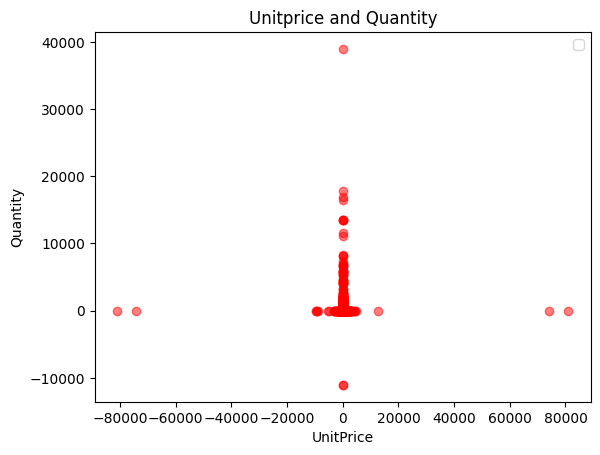

In [12]:
plt.scatter(data['Quantity'],data['UnitPrice'],color='red',alpha=0.5)
plt.legend()
plt.title('Unitprice and Quantity')
plt.xlabel('UnitPrice')
plt.ylabel('Quantity')
plt.show() 

In [13]:
words=['POST','DOT','M','C2','D','S','BANK CHARGES','AMAZONFEE','CRUK','B','ADJUST','ADJUST2']
data=data[data.UnitPrice > 0]
data['StockCode'] = data['StockCode'].astype(str).str.upper()
data=data[~data.StockCode.isin(words)].copy()
data['cancel']=data.InvoiceNo.astype(str).str.startswith('C').astype(int)
q=data.Quantity.abs()
data['lq']=np.log1p(q.clip(upper=q.quantile(.999)))

In [14]:
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

In [ ]:
X,y=train_test_split(data, test_size=.2, random_state=42)

cat_cols=['StockCode', 'Country', 'month'] 
features=cat_cols + ['lq', 'cancel']
y_train,y_test=X.UnitPrice.values, y.UnitPrice.values

def fit_predict(model):
    prep=ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)],remainder='passthrough')
    pipe=make_pipeline(prep,model)

    y_log=np.log1p(y_train)
    pipe.fit(X[features],y_log)

    correction=np.mean(np.exp(y_log - pipe.predict(X[features])))
    pred=np.exp(pipe.predict(y[features])) * correction - 1
    return np.clip(pred,0,None)

models={'LinearRegression': LinearRegression(),}


for name, m in models.items():
    p=fit_predict(m)
    print(name,'R2 =',round(r2_score(y_test, p), 4),'RMSE =',round(np.sqrt(mean_squared_error(y_test, p)),4))

LinearRegression R2 = 0.8584 RMSE = 1.6033
